# **U-Net 모델 구현**

✅ 아래 코드는 PyTorch로 작성한 간단한 U-Net 모델입니다.

✅ 주요 목표: 작은 이미지 세트로 segmentation 학습을 테스트하기!

✅ 특징: 업샘플링(deconv/upsample 선택 가능), 입력 스케일링, Gaussian noise 추가, 배치 정규화 적용

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# --- 작은 U-Net 정의 ---
class UNetSmall(nn.Module):
    def __init__(self, upsample_mode='deconv', net_scaling=None, edge_crop=0, gaussian_noise_std=0.1):
        super().__init__()
        self.net_scaling = net_scaling
        self.edge_crop = edge_crop
        self.gaussian_noise_std = gaussian_noise_std
        self.upsample_mode = upsample_mode

         # Convolution Block: Conv -> ReLU -> Conv -> ReLU
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.ReLU(inplace=True)
            )

        # 인코더 부분 목표 -> 128 까지!
        self.enc1 = conv_block(3, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.enc4 = conv_block(256, 512)
        # Bottleneck
        self.center = conv_block(512, 128)
        self.pool = nn.MaxPool2d(2)


        # 업샘플링 부분 정의 (deconv 또는 upsample+conv) 로
        if upsample_mode == 'deconv':
            def upsample_layer(in_c, out_c):
                return nn.ConvTranspose2d(in_c, out_c, 2, stride=2)
        else:
            def upsample_layer(in_c, out_c):
                return nn.Sequential(
                    nn.Upsample(scale_factor=2, mode='nearest'),
                    nn.Conv2d(in_c, out_c, 1)
                )
        # 디코더 부분
        self.up4 = upsample_layer(128, 512)
        self.dec4 = conv_block(512+512, 256)
        self.up3 = upsample_layer(256, 256)
        self.dec3 = conv_block(256+256, 128)
        self.up2 = upsample_layer(128, 128)
        self.dec2 = conv_block(128+128, 64)
        self.up1 = upsample_layer(64, 64)
        self.dec1 = conv_block(64+64, 32)

        # 최종 출력: 1채널(segmentation mask)
        self.final = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        if self.net_scaling:
        # 입력 스케일링
            x = F.avg_pool2d(x, self.net_scaling)
        # Gaussian noise 추가
        if self.gaussian_noise_std:
            noise = torch.randn_like(x) * self.gaussian_noise_std
            x = x + noise

        # 배치 정규화 적용
        x = F.batch_norm(x, running_mean=None, running_var=None, training=True)

        # 인코더
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        # Bottleneck
        center = self.center(self.pool(e4))

        # 디코더 + Skip Connection
        d4 = self.up4(center)
        d4 = torch.cat([d4,e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        out = self.final(d1)
        out = torch.sigmoid(out)
         # Crop + Pad
        if self.edge_crop > 0:
            out = out[:, :, self.edge_crop:-self.edge_crop, self.edge_crop:-self.edge_crop]
            out = F.pad(out, (self.edge_crop, self.edge_crop, self.edge_crop, self.edge_crop))
        # Upsample 다시 확대
        if self.net_scaling:
            out = F.interpolate(out, scale_factor=self.net_scaling, mode='nearest')

        return out


## **학습용 데이터 생성하기**

In [2]:
batch_size = 32
x = torch.randn(batch_size, 3, 128, 128)  # RGB 이미지
y = (torch.rand(batch_size, 1, 128, 128) > 0.5).float()  # 랜덤 이진 마스크

dataset = TensorDataset(x, y)
loader = DataLoader(dataset, batch_size=2, shuffle=True)

## **데이터 시각화**

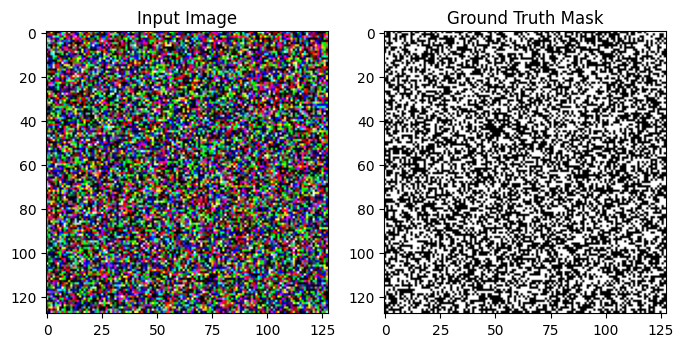

In [3]:
import matplotlib.pyplot as plt
# 첫 번째 이미지를 시각화
sample_x = x[0]
sample_y = y[0]

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(sample_x.permute(1, 2, 0).numpy())
plt.title('Input Image')

plt.subplot(1, 2, 2)
plt.imshow(sample_y.squeeze().numpy(), cmap='gray')
plt.title('Ground Truth Mask')
plt.show()

## **모델 선언 및 학습**

In [4]:
# --- 모델 선언 및 학습 ---
model = UNetSmall(upsample_mode='deconv', net_scaling=None, edge_crop=0)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCELoss()

# 간단히 30 epoch만
for epoch in range(10):
    model.train()
    total_loss = 0
    for xb, yb in loader:
        pred = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

Epoch 1, Loss: 0.6932
Epoch 2, Loss: 0.6931
Epoch 3, Loss: 0.6930
Epoch 4, Loss: 0.6929
Epoch 5, Loss: 0.6926
Epoch 6, Loss: 0.6922
Epoch 7, Loss: 0.6915
Epoch 8, Loss: 0.6904
Epoch 9, Loss: 0.6892
Epoch 10, Loss: 0.6878


## **아래 주석을 풀고 U-Net 모델에 대해 간단히 설명해주세요 😀**

[답변]


---
- 바이오 메디컬 이미지 분할을 위한 합성곱 신경망
- 속도가 빠름 : 이미 검증이 끝난 패치는 건너뛰기
- Trade-Off에 빠지지 않음 : 컨텍스트 인식과 지역화 트레이드오프 문제를 개선
- FCN을 기반으로 구축, 수축경로와 확장경로로 구성
  - 수축 경로 : 컨텍스트 포착
  - 확장 경로 : 특성 맵을 업 샘플링하고 수축 경로에서 포착한 특성 맵의 컨텍스트와 결합하여 정확한 지역화 수행

- U자형 구조 → 인코더 (downsampling) + 디코더 (upsampling) + skip connection
  - 인코터 : 컨볼루션 + 풀링으로 feature를 추출하고 크기를 점점 줄임
  - 디코더 : 업샘플링 (deconvolution 등)을 통해 feature map 크기를 복원
  - Skip connection : 인코더의 feature를 디코더로 연결하여 위치 정보 보존 (세밀한 경계 복원에 도움)

- 장점 : 적은 데이터로도 좋은 성능, 위치 정보를 잘 살릴 수 있음

## **아래 주석을 풀고 DeepLabv1, v2, v3. v3+  모델에 대해 각각 간단히 설명해주세요 🐶**

[답변]


---

[DeepLab v1]
- Atrous convolution (Hole algorithm) 도입 : 다운샘플 없이 넓은 리셉티브 필드 확보
- Fully Connected CRF (FC-CRF) → DCNN이 놓친 경계 정보를 후처리로 보완
- 목표: Downsampling으로 인해 손실되는 공간적 세부정보 복원, 세밀한 경계 표현 가능하도록 후처리 (FC-CRF)
---
[DeepLab v2]
- ASPP (Atrous Spatial Pyramid Pooling) 도입 : 다양한 dilation rate로 multi-scale feature 추출 가능
- Atrous convolution + FC-CRF 조합 유지
- 목표: 물체 크기 다양성 대응 → 여러 스케일에서 인식 가능, 더 정교한 multi-scale 표현
---
[DeepLab v3]
- ASPP 개선 (Augmented ASPP) → Global Average Pooling 추가 → 더 풍부한 context 반영
- FC-CRF 제거 → 네트워크만으로 충분히 정교해짐
- 목표: CRF 없이도 좋은 성능 → 경계 정보 잘 보존, 다양한 receptive field 확보 + 단일 네트워크 학습 최적화
---
[DeepLab v3+]
- Encoder-Decoder 구조 도입 : spatial detail 복원 강화
- Depthwise Separable Atrous Convolution → 연산량 절감 + 경량화
- 목표: 복잡한 decoder 대신 효율적인 decoder → 경계 세밀하게 복원, Depthwise separable로 속도와 메모리 효율 향상